# Analisis exploratorio

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

### Cargue de la base

In [2]:
fuente = "BBDD Prueba Analista II - Lealtad.xlsx"
df = pd.read_excel(fuente)
df.head(5)

,Fondo_Destino,Tipo_Id,Id,Traslado,probChurn_afp,Cla_Value_Cliente,Primer_nombre,Productos,Ruta_Porvenir,Segmento,...,Cla_Densidad_Cot,Tipo_Cotizante_PO,Estado,SubEstado,Tipo_Afiliado,Observaciones,Grupo,N_Campañas,acum_tmk_anterior,Gestión_Final_Anterior
0,2-AFP,CC,1,NO,0.9167,Entre 5MM y <10MM,CARLOS,PO,CONSTRUYENDO,PLATINO,...,Mayor o igual 75%,Activo,VIGENTE,TRASLADO_ENTRADA,DEPENDIENTE,Correo_Celular,Mayor_Valor,7.0,NaN,NaN
1,2-AFP,CC,2,NO,0.9167,Entre 5MM y <10MM,JAVIER,PO,CONSTRUYENDO,DORADO,...,Mayor o igual 75%,Activo,VIGENTE,TRASLADO_ENTRADA,INDEPENDIENTE_VOLUNTARIO,Celular,Mayor_Valor,3.0,efectivo,efectivo
2,2-AFP,CC,3,SI,0.9167,Entre 5MM y <10MM,ROSSI,POPI,CONSTRUYENDO,DORADO,...,Mayor o igual 75%,Activo,VIGENTE,TRASLADO_ENTRADA,DEPENDIENTE,Celular,Mayor_Valor,3.0,NaN,efectivo
3,2-AFP,PE,4,NO,0.9167,Entre 2MM y <5MM,MARIA,PO,CONSTRUYENDO,DORADO,...,Mayor o igual 75%,Inactivo,VIGENTE,INICIAL,DEPENDIENTE,Celular,Mayor_Valor,3.0,NaN,NaN
4,2-AFP,CC,5,NO,0.9167,Entre 2MM y <5MM,ANDRES,POCES,GEN. PORVENIR,DORADO,...,Mayor o igual 75%,Activo,VIGENTE,INICIAL,DEPENDIENTE,Correo_Celular,GEN. PORVENIR,2.0,efectivo,efectivo


Validación del tipo de variables

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101725 entries, 0 to 101724
Data columns (total 33 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Fondo_Destino           101725 non-null  object 
 1   Tipo_Id                 101725 non-null  object 
 2   Id                      101725 non-null  int64  
 3   Traslado                101725 non-null  object 
 4   probChurn_afp           101724 non-null  float64
 5   Cla_Value_Cliente       101724 non-null  object 
 6   Primer_nombre           101725 non-null  object 
 7   Productos               101716 non-null  object 
 8   Ruta_Porvenir           101725 non-null  object 
 9   Segmento                101725 non-null  object 
 10  Genero                  101725 non-null  object 
 11  Edad                    101724 non-null  float64
 12  Años_Pension            101724 non-null  float64
 13  Salario                 101724 non-null  float64
 14  Saldo               

De todas las variables numéricas sacamos sus estadísticas varibles iniciales (Promedio, valor mínimo, valor máximo, desviación estándar

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,101725.0,50863.000000,29365.622404,1.0000,25432.000,50863.0000,76294.0000,101725.0000
probChurn_afp,101724.0,0.849207,0.021809,0.7996,0.839,0.8468,0.8635,0.9388
Edad,101724.0,31.615263,6.931088,13.0000,26.000,31.0000,37.0000,46.0000
Años_Pension,101724.0,28.391353,6.972294,16.0000,23.000,29.0000,34.0000,49.0000
Salario,101724.0,3575.520723,1560.994948,1000.0000,2270.000,3537.0000,4804.0000,9000.0000
Saldo,101302.0,196.367466,167.624349,1.0000,56.000,141.0000,327.0000,1000.0000
Antiguedad,101723.0,8.375461,6.119546,0.0000,4.000,6.0000,13.0000,28.0000
Semanas_Cotizadas,101725.0,647.173143,230.512034,400.0000,472.000,544.0000,922.0000,1300.0000
N_Campañas,79059.0,3.601753,1.992359,1.0000,2.000,3.0000,5.0000,10.0000


Cuantos valores únicos posee cada variable

In [5]:
df.nunique()

Fondo_Destino                  2
Tipo_Id                        5
Id                        101725
Traslado                       2
probChurn_afp                581
Cla_Value_Cliente              4
Primer_nombre               8748
Productos                      6
Ruta_Porvenir                  2
Segmento                       4
Genero                         2
Edad                          31
Años_Pension                  30
Salario                     5794
Saldo                        978
Ciudad                       893
Departamento                  34
Tiene_Correo                   1
Celular_Duplicado              1
Tiene_Celular                  1
Autoriza_Contacto              2
Antiguedad                    29
Semanas_Cotizadas            602
Cla_Densidad_Cot               4
Tipo_Cotizante_PO              2
Estado                         1
SubEstado                      5
Tipo_Afiliado                  7
Observaciones                  3
Grupo                          3
N_Campañas

Calculo del % de missing values

In [6]:
(df.isnull().sum()/(len(df)))*100

Fondo_Destino              0.000000
Tipo_Id                    0.000000
Id                         0.000000
Traslado                   0.000000
probChurn_afp              0.000983
Cla_Value_Cliente          0.000983
Primer_nombre              0.000000
Productos                  0.008847
Ruta_Porvenir              0.000000
Segmento                   0.000000
Genero                     0.000000
Edad                       0.000983
Años_Pension               0.000983
Salario                    0.000983
Saldo                      0.415827
Ciudad                     0.052101
Departamento               0.052101
Tiene_Correo              21.879577
Celular_Duplicado         99.909560
Tiene_Celular             15.066110
Autoriza_Contacto         49.688867
Antiguedad                 0.001966
Semanas_Cotizadas          0.000000
Cla_Densidad_Cot           0.002949
Tipo_Cotizante_PO          0.002949
Estado                     0.001966
SubEstado                  0.001966
Tipo_Afiliado              0

Se detectan missing values en múltiples columnas por lo que se procede a corregir esas variables con metodo de imputación dependiendo del promedio o la mediana dependiendo de la variable, sin embargo hay multiples variables que están con demasiados missing values por lo que su calidad está comprometida, razón por la cuál serán retiradas más adelante.

### Corrección missing values

In [7]:
df['probChurn_afp'] = df['probChurn_afp'].fillna(
    df.groupby(['Ruta_Porvenir','Segmento', 'Genero','Semanas_Cotizadas', 'Grupo'])['probChurn_afp'].transform('median')
)
df['Cla_Value_Cliente'] = df['Cla_Value_Cliente'].fillna(
    df.groupby(['Ruta_Porvenir','Segmento', 'Genero','Semanas_Cotizadas', 'Grupo'])['Cla_Value_Cliente'].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)
df['Productos'] = df['Productos'].fillna(
    df.groupby(['Ruta_Porvenir','Segmento', 'Genero','Semanas_Cotizadas', 'Grupo'])['Productos'].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)
df['Edad'] = df['Edad'].fillna(
    df.groupby(['Ruta_Porvenir','Segmento', 'Genero','Semanas_Cotizadas', 'Grupo'])['Edad'].transform('median')
)
df['Años_Pension'] = df['Años_Pension'].fillna(
    df.groupby(['Ruta_Porvenir','Segmento', 'Genero','Semanas_Cotizadas', 'Grupo'])['Años_Pension'].transform('median')
)
df['Salario'] = df['Salario'].fillna(
    df.groupby(['Ruta_Porvenir','Segmento', 'Genero','Semanas_Cotizadas', 'Grupo'])['Salario'].transform('median')
)
df['Saldo'] = df['Saldo'].fillna(
    df.groupby(['Ruta_Porvenir','Segmento', 'Genero','Semanas_Cotizadas', 'Grupo'])['Saldo'].transform('median')
)
df['Ciudad'] = df['Ciudad'].fillna(
    df.groupby(['Ruta_Porvenir','Segmento', 'Genero','Semanas_Cotizadas', 'Grupo'])['Ciudad'].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)
df['Departamento'] = df['Departamento'].fillna(
    df.groupby(['Ruta_Porvenir','Segmento', 'Genero','Semanas_Cotizadas', 'Grupo'])['Departamento'].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)
df['Antiguedad'] = df['Antiguedad'].fillna(
    df.groupby(['Ruta_Porvenir','Segmento', 'Genero','Semanas_Cotizadas', 'Grupo'])['Antiguedad'].transform('median')
)
df['Cla_Densidad_Cot'] = df['Cla_Densidad_Cot'].fillna(
    df.groupby(['Ruta_Porvenir','Segmento', 'Genero','Semanas_Cotizadas', 'Grupo'])['Cla_Densidad_Cot'].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)
df['Tipo_Cotizante_PO'] = df['Tipo_Cotizante_PO'].fillna(
    df.groupby(['Ruta_Porvenir','Segmento', 'Genero','Semanas_Cotizadas', 'Grupo'])['Tipo_Cotizante_PO'].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)
df['Estado'] = df['Estado'].fillna(
    df.groupby(['Ruta_Porvenir','Segmento', 'Genero','Semanas_Cotizadas', 'Grupo'])['Estado'].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)
df['SubEstado'] = df['SubEstado'].fillna(
    df.groupby(['Ruta_Porvenir','Segmento', 'Genero','Semanas_Cotizadas', 'Grupo'])['SubEstado'].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)
df['Tipo_Afiliado'] = df['Tipo_Afiliado'].fillna(
    df.groupby(['Ruta_Porvenir','Segmento', 'Genero','Semanas_Cotizadas', 'Grupo'])['Tipo_Afiliado'].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)
df['N_Campañas'] = df['N_Campañas'].fillna(
    df.groupby(['Ruta_Porvenir','Segmento', 'Genero','Semanas_Cotizadas', 'Grupo'])['N_Campañas'].transform('median')
)

Se eliminan las primeras variables no relevantes

In [8]:
df_v2 = df.drop(['Gestión_Final_Anterior','acum_tmk_anterior','Tiene_Celular','Autoriza_Contacto','Celular_Duplicado','Tiene_Correo','Id','Primer_nombre'],axis=1)

In [9]:
df_v2.head()

,Fondo_Destino,Tipo_Id,Traslado,probChurn_afp,Cla_Value_Cliente,Productos,Ruta_Porvenir,Segmento,Genero,Edad,...,Antiguedad,Semanas_Cotizadas,Cla_Densidad_Cot,Tipo_Cotizante_PO,Estado,SubEstado,Tipo_Afiliado,Observaciones,Grupo,N_Campañas
0,2-AFP,CC,NO,0.9167,Entre 5MM y <10MM,PO,CONSTRUYENDO,PLATINO,M,46.0,...,5.0,529,Mayor o igual 75%,Activo,VIGENTE,TRASLADO_ENTRADA,DEPENDIENTE,Correo_Celular,Mayor_Valor,7.0
1,2-AFP,CC,NO,0.9167,Entre 5MM y <10MM,PO,CONSTRUYENDO,DORADO,M,39.0,...,2.0,568,Mayor o igual 75%,Activo,VIGENTE,TRASLADO_ENTRADA,INDEPENDIENTE_VOLUNTARIO,Celular,Mayor_Valor,3.0
2,2-AFP,CC,SI,0.9167,Entre 5MM y <10MM,POPI,CONSTRUYENDO,DORADO,F,36.0,...,5.0,538,Mayor o igual 75%,Activo,VIGENTE,TRASLADO_ENTRADA,DEPENDIENTE,Celular,Mayor_Valor,3.0
3,2-AFP,PE,NO,0.9167,Entre 2MM y <5MM,PO,CONSTRUYENDO,DORADO,F,38.0,...,4.0,527,Mayor o igual 75%,Inactivo,VIGENTE,INICIAL,DEPENDIENTE,Celular,Mayor_Valor,3.0
4,2-AFP,CC,NO,0.9167,Entre 2MM y <5MM,POCES,GEN. PORVENIR,DORADO,M,23.0,...,3.0,549,Mayor o igual 75%,Activo,VIGENTE,INICIAL,DEPENDIENTE,Correo_Celular,GEN. PORVENIR,2.0


### Datos después del ajuste de missing values

In [10]:
df_v2.describe().T

,count,mean,std,min,25%,50%,75%,max
probChurn_afp,101725.0,0.849207,0.021809,0.7996,0.839,0.8468,0.8635,0.9388
Edad,101725.0,31.615281,6.931057,13.0000,26.000,31.0000,37.0000,46.0000
Años_Pension,101725.0,28.391354,6.972260,16.0000,23.000,29.0000,34.0000,49.0000
Salario,101725.0,3575.515478,1560.988172,1000.0000,2270.000,3537.0000,4804.0000,9000.0000
Saldo,101724.0,195.832744,167.526945,1.0000,56.000,139.0000,326.0000,1000.0000
Antiguedad,101725.0,8.375611,6.119581,0.0000,4.000,6.0000,13.0000,28.0000
Semanas_Cotizadas,101725.0,647.173143,230.512034,400.0000,472.000,544.0000,922.0000,1300.0000
N_Campañas,101654.0,3.469337,1.815105,1.0000,2.000,3.0000,5.0000,10.0000


Separamos las variables numéricas y categóricas para el análisis univariado

In [11]:
cat_cols=df_v2.select_dtypes(include=['object']).columns
num_cols = df_v2.select_dtypes(include=np.number).columns.tolist()
print("Categorical Variables:")
print(cat_cols)
print("Numerical Variables:")
print(num_cols)

Categorical Variables:
Index(['Fondo_Destino', 'Tipo_Id', 'Traslado', 'Cla_Value_Cliente',
       'Productos', 'Ruta_Porvenir', 'Segmento', 'Genero', 'Ciudad',
       'Departamento', 'Cla_Densidad_Cot', 'Tipo_Cotizante_PO', 'Estado',
       'SubEstado', 'Tipo_Afiliado', 'Observaciones', 'Grupo'],
      dtype='object')
Numerical Variables:
['probChurn_afp', 'Edad', 'Años_Pension', 'Salario', 'Saldo', 'Antiguedad', 'Semanas_Cotizadas', 'N_Campañas']


# Analisis Univariado

### Graficos boxplot e histogramas

probChurn_afp
Skew : 0.08


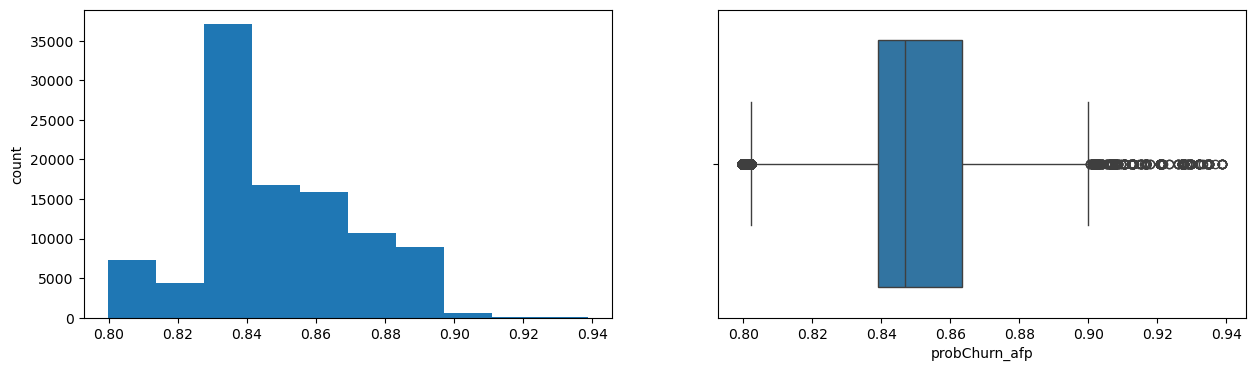

Edad
Skew : 0.34


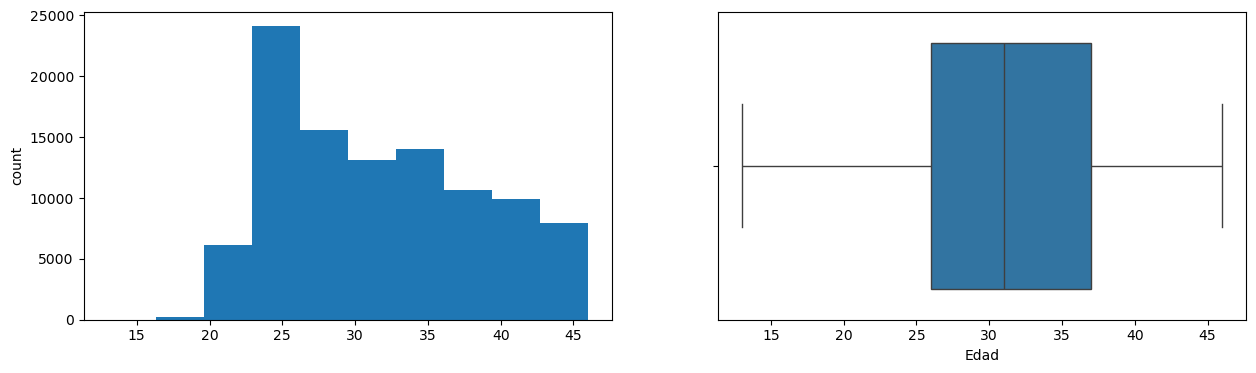

Años_Pension
Skew : -0.11


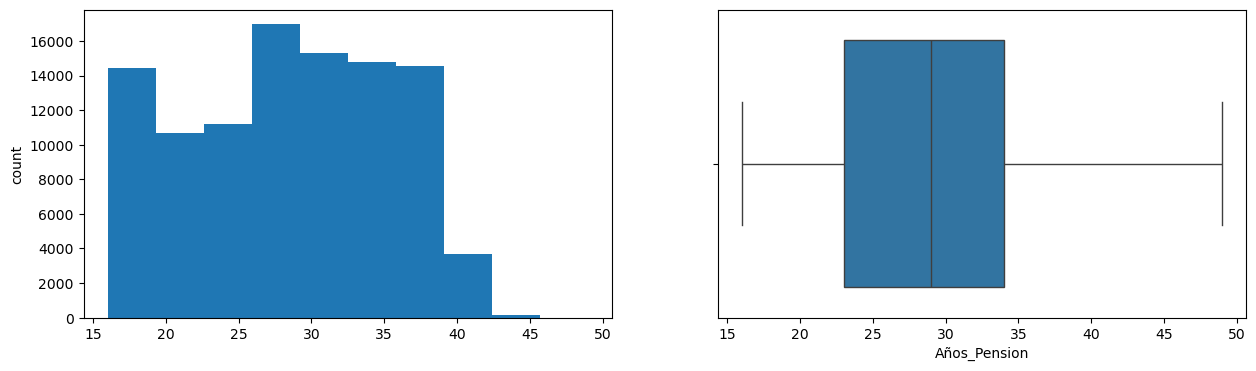

Salario
Skew : 0.37


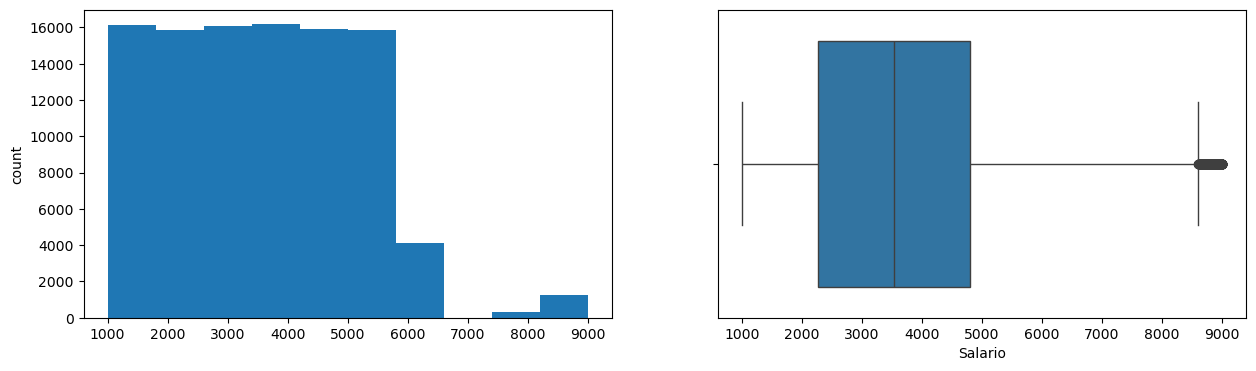

Saldo
Skew : 0.97


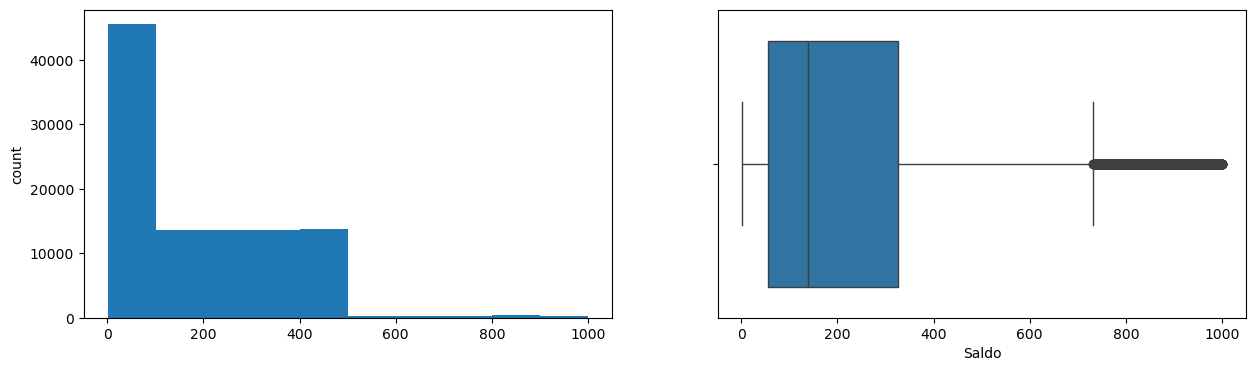

Antiguedad
Skew : 0.86


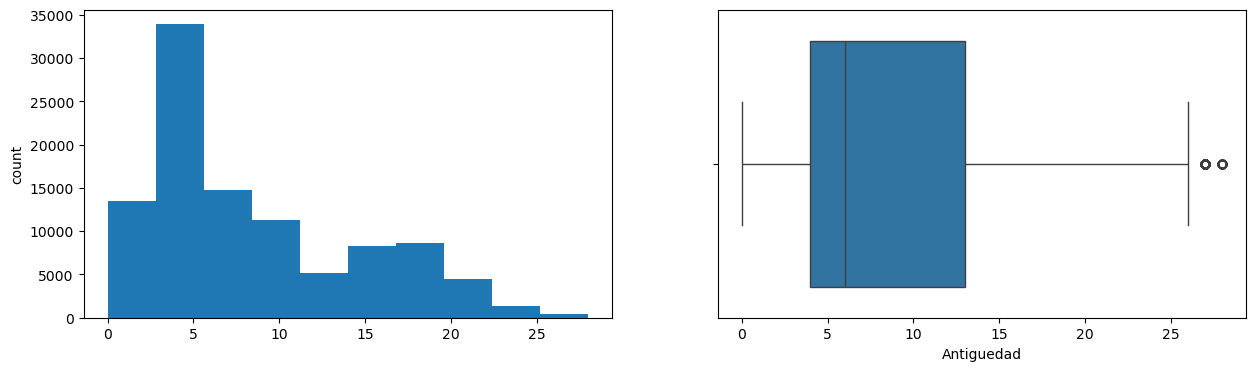

Semanas_Cotizadas
Skew : 0.84


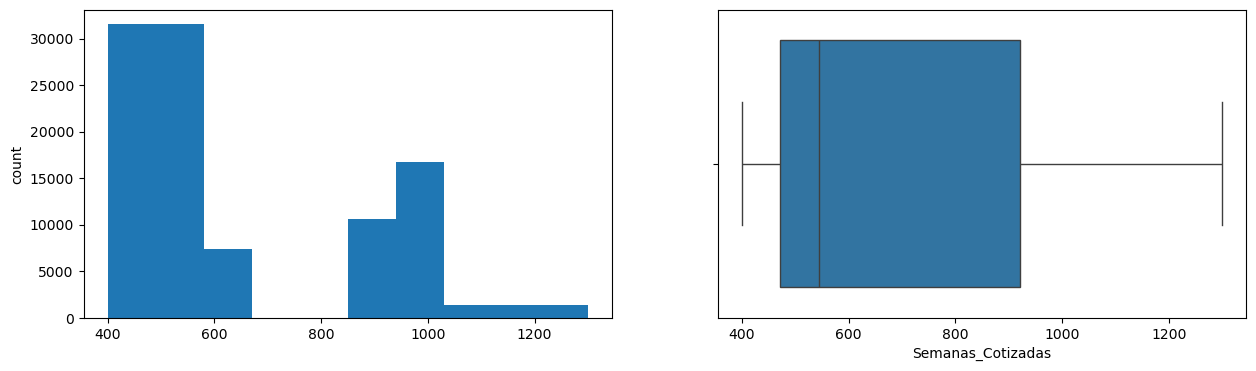

N_Campañas
Skew : 0.58


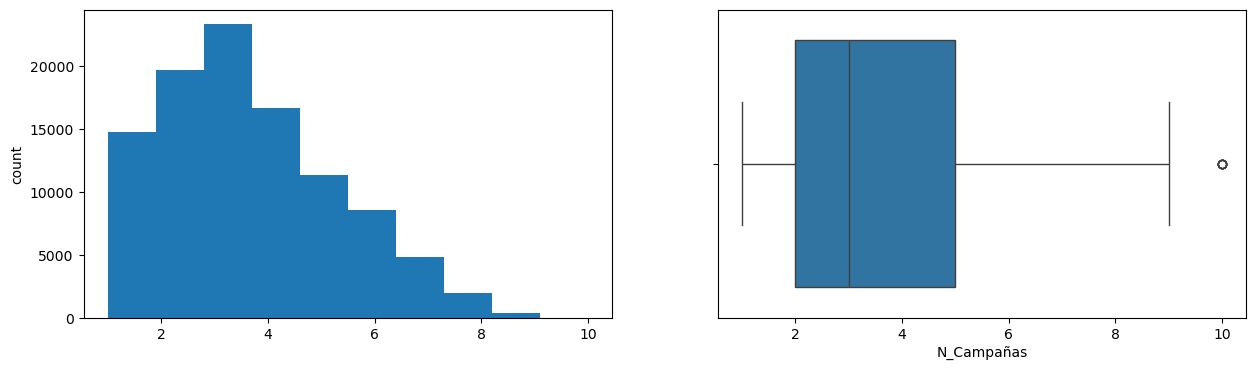

In [12]:
for col in num_cols:
    print(col)
    print('Skew :', round(df_v2[col].skew(), 2))
    plt.figure(figsize = (15, 4))
    plt.subplot(1, 2, 1)
    df_v2[col].hist(grid=False)
    plt.ylabel('count')
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df_v2[col])
    plt.show()

Se observa lo siguiente:
* La mayor frecuencia de la **edad** de poblacion se mueve entre 25-37 años, lo cual es esperado dado la relativa juventud de la población.
* En la variable **probChurn_afp** muestra datos atípicos en el sector superior con probabilidades muy altas y muchas más en el sector inferior con probabilidades <= 0.82.
* La variable **años-pensión** muestra una serie de datos atípicos en el extremo superior lo cual nos sirve para identificar a clientes ya fidelizados.
* En **salario** observamos que hay una distribución bastante uniforme en los valores entre 1000 y 5500, sin embargo después de eso se oberva una enorme brecha en donde disminuye cada vez más la cantidad de clientes con un mayor ingreso hasta el punto en donde se llega a ingresos mayores a 8250 en donde a pesa de ser una minoria en la poblacion, esta ha ido aumentando en cantidad. 
* En **N_campañas** se observa que la mayoría de los clientes están congregados entre 2 y 5 años pero después de ese periodo empieza a disminución de clientes en afiliacion.
* En **antiguedad** se puede observar que la mayoría de clientes permanecen afiliados por mucho 5 años y después empieza un declive masivo de clientes, hasta el punto en el que al llevar más de 15 años afiliados es muy dificil que los clientes se vayan y por el contrario la cifra comienza a aunmentar, esto indica que hay una oportunidad de consolidación de ingresos a largo plazo si se idea una estrategia de fidelidad para clientes que lleven más de 10 años en esta compañía.
* En **semanas cotizadas** vemos que la mayoría de los clientes esta divididos en 2 grupos, el primero es de gente más o menos ya consolidada a nivel laboral y con mas de 5 años experiencia pero menos de 13 años, este gurpo puede ser de gran potencial a mediano y largo plazo por lo que ofertas que les presente mayores rentabilidades o mayores beneficios podria ayudar con los temas de fidelización. El otro grupo es el de entre 16 y 21 años que es el caso en donde hay clientes ya fidelizados pero que aún tienen chance de cambiar de entidad pensinal sin embargo al llevar tanto tiempo con ellos resulta muy poco posible, por último hay unos casos atípicos en donde hay gente que tiene mas de 20 años cotizados afiliados en la compañía que ya no tienen forma de cambio de entidad y vienen a culminar su proceso de pensión en la compañía.

### Analisis variables categóricas

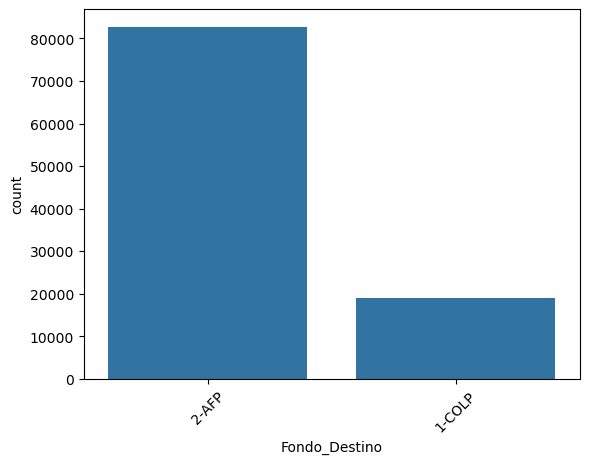

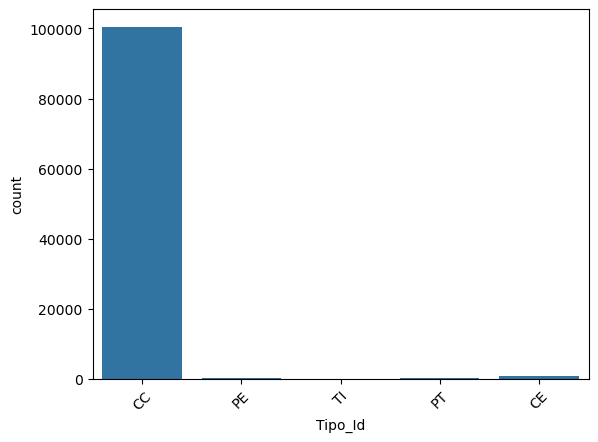

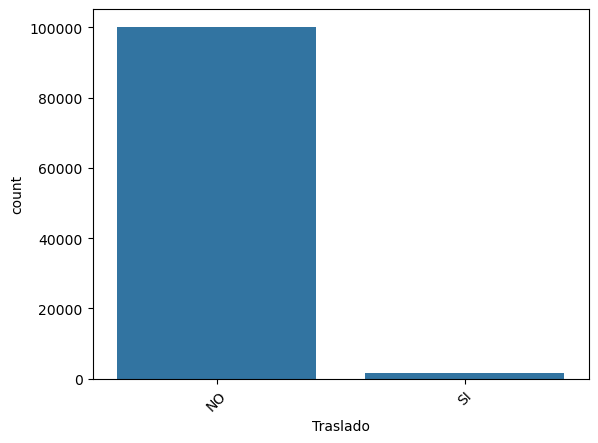

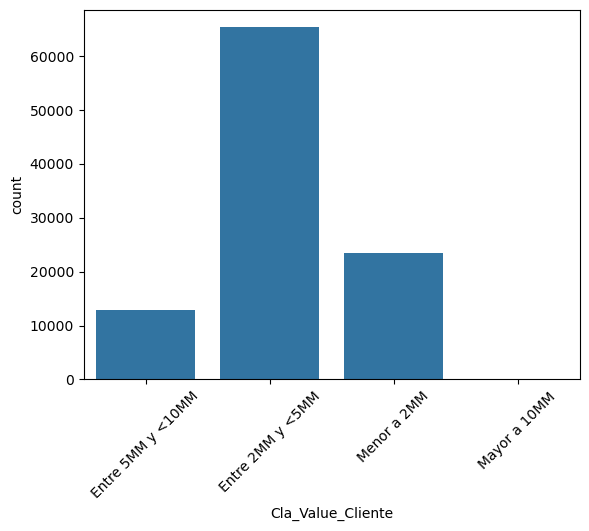

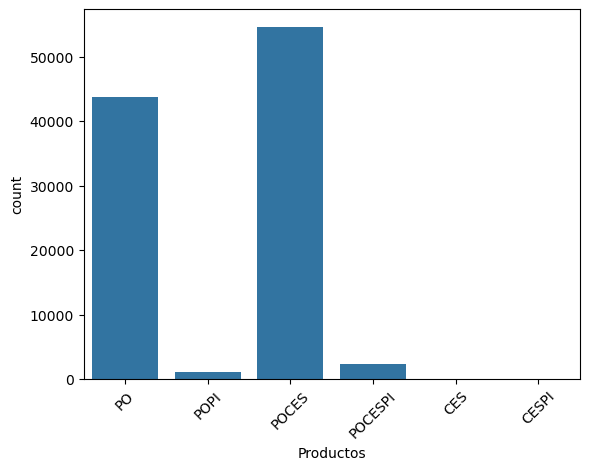

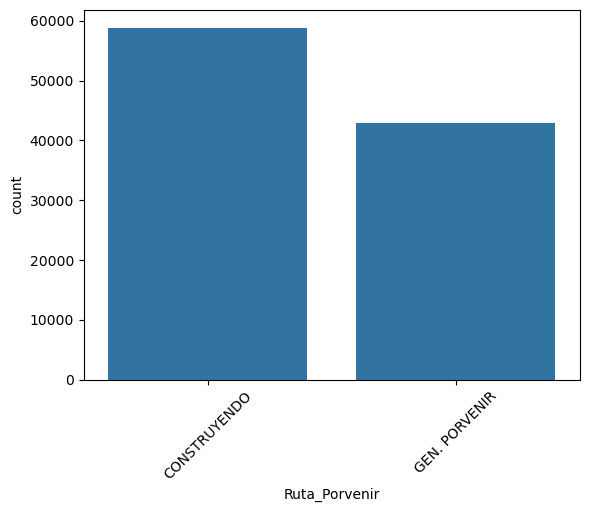

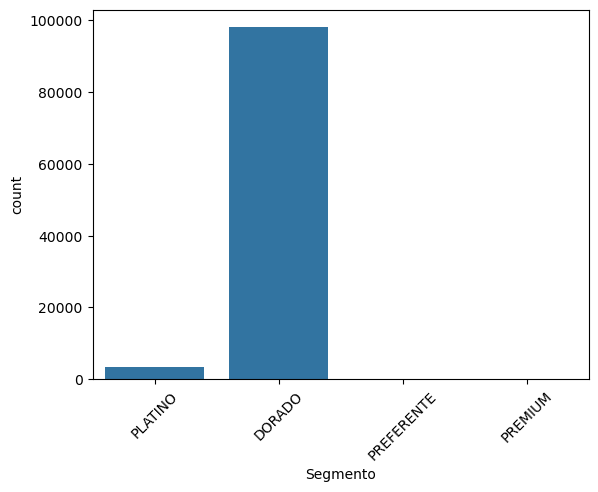

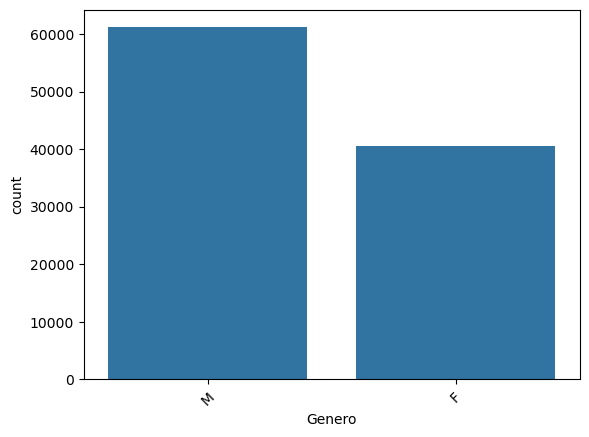

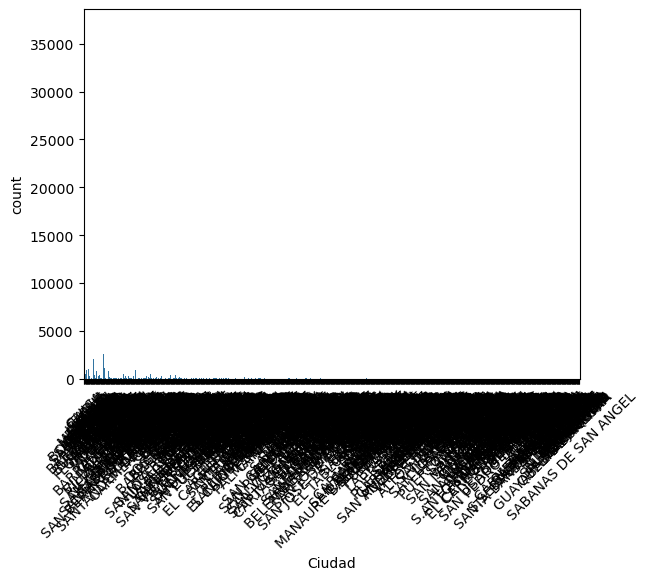

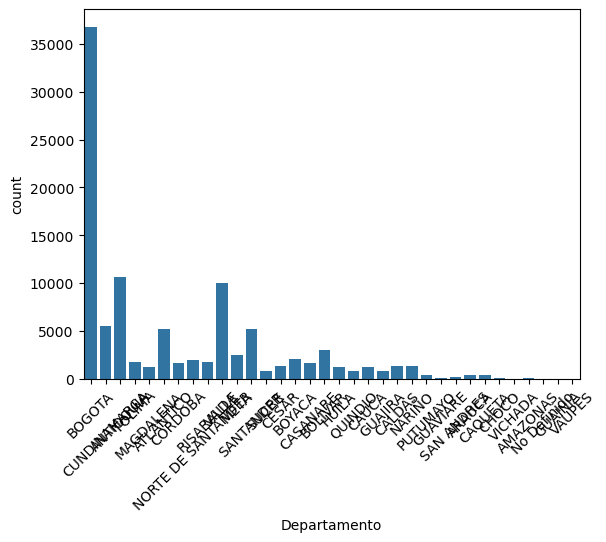

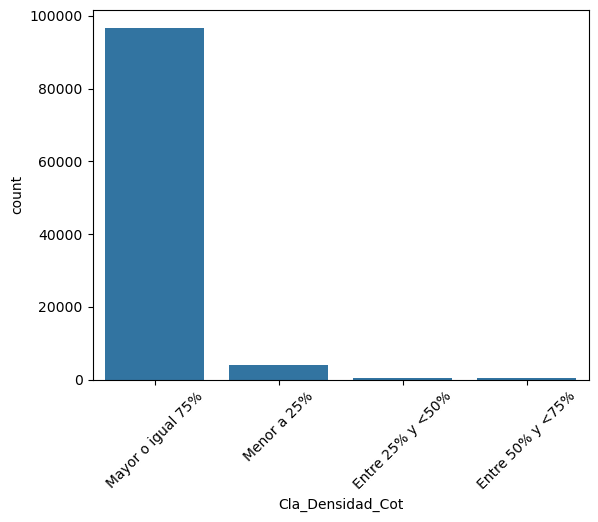

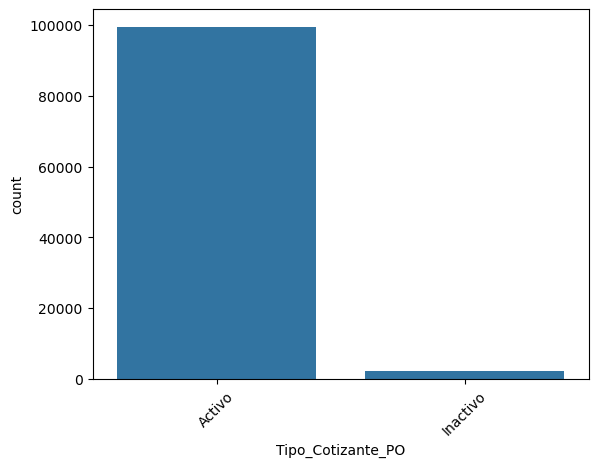

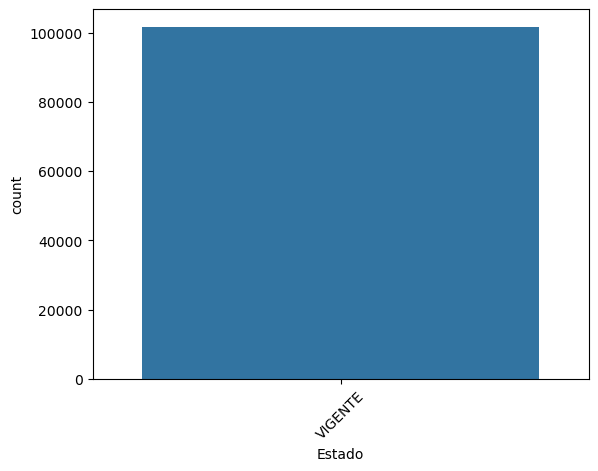

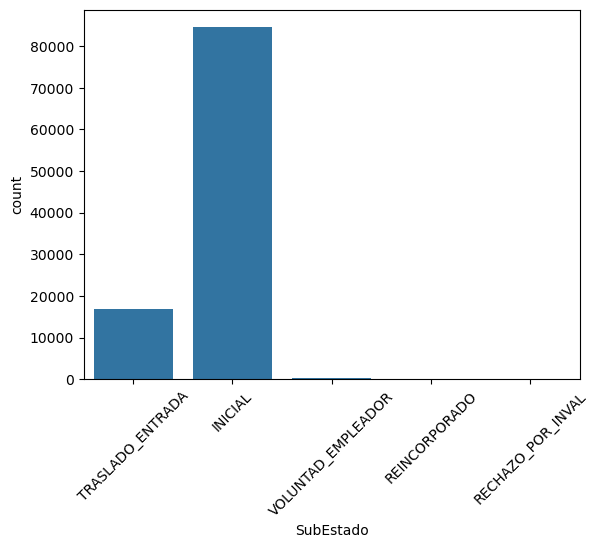

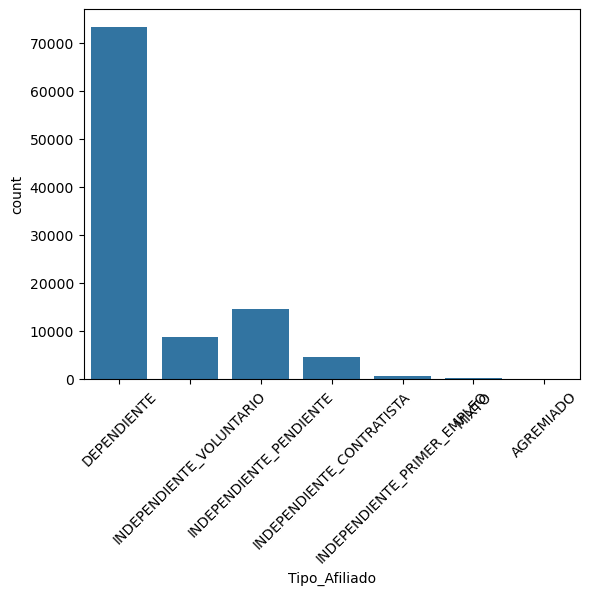

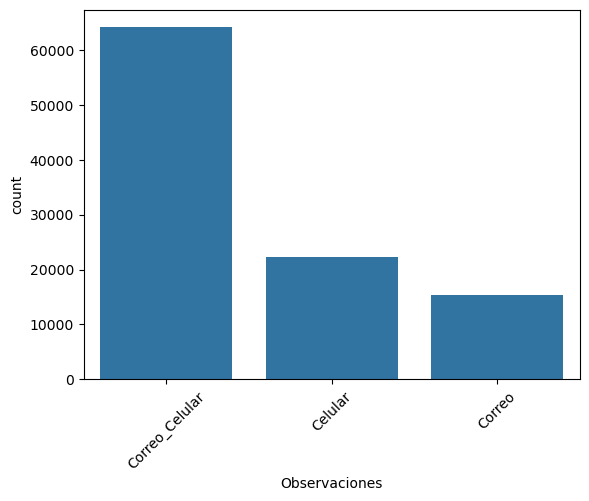

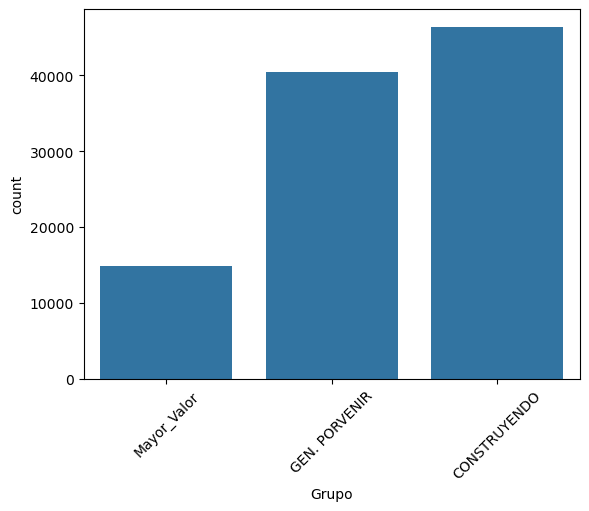

In [13]:
for col in cat_cols:
    sns.countplot(data=df_v2, x=col)
    plt.xticks(rotation=45)
    plt.show()

Se observa lo siguiente:
* La mayor frecuencia de **Fondo_Destino** provienen de AFP privadas tales como podrían ser (Skandia, Protección y la propia Porvenir) y la razón de ello puede ser a mayores rentabilidades de sus fondos al afiliarse con la entidad.
* En la variable **Traslado** se observa que para la mayoria de clentes somos su primera entidad de fondos de pensión, lo que es una buena señal de popularidad entre personas que recién inician en el mercado laboral.
* La variable **Cla_value_cliente** muestra que una vasta mayoría de los clientes pertenecen a ingresos medios que se ubican entre 2 y 5 millones de pesos lo que confirma lo mencionado en la información de traslado, mientras que  los clientes de ingresos menores a 10 millones son un poco mas del 15% eso conlleva a que si se buscara afianzar a este tipo de clientes hay que buscar estrategias de mayor rentabilidad para capitalizar sus aporte a un mediano y largo plazo.
* En **Tipo_afiliado** observamos que la mayoría de los clientes son empleados de alguna empresa/agencia, lo que permitiría afianzar más a los clientes a través de una mayor variedad de productos de portafolio como lo sería la incorporación de cesantías o  el ofrecimiento de una poliza de seguros de desempleo en caso de despido a través de una alianza con una aseguradora. 
* En **Subestado** se confirma lo dicho previamente acerca de que el estado de nuestros clientes es de que están en su primer empleo por lo que campañas de educacion financiera y presentacion de portafolio podrían aydar en el afianzamiento de clientes.
* En **departamento** se puede observar que la mayoría de clientes provienen de la ciudad de Bogotá, seguido de Cundinamarca, Antioquia y Atlántico por lo que campañas de afiliación dentro de las empresas de estos departamentos pueden ayudar a atraer clientes de ingresos medios y altos.

### Analisis bivariado

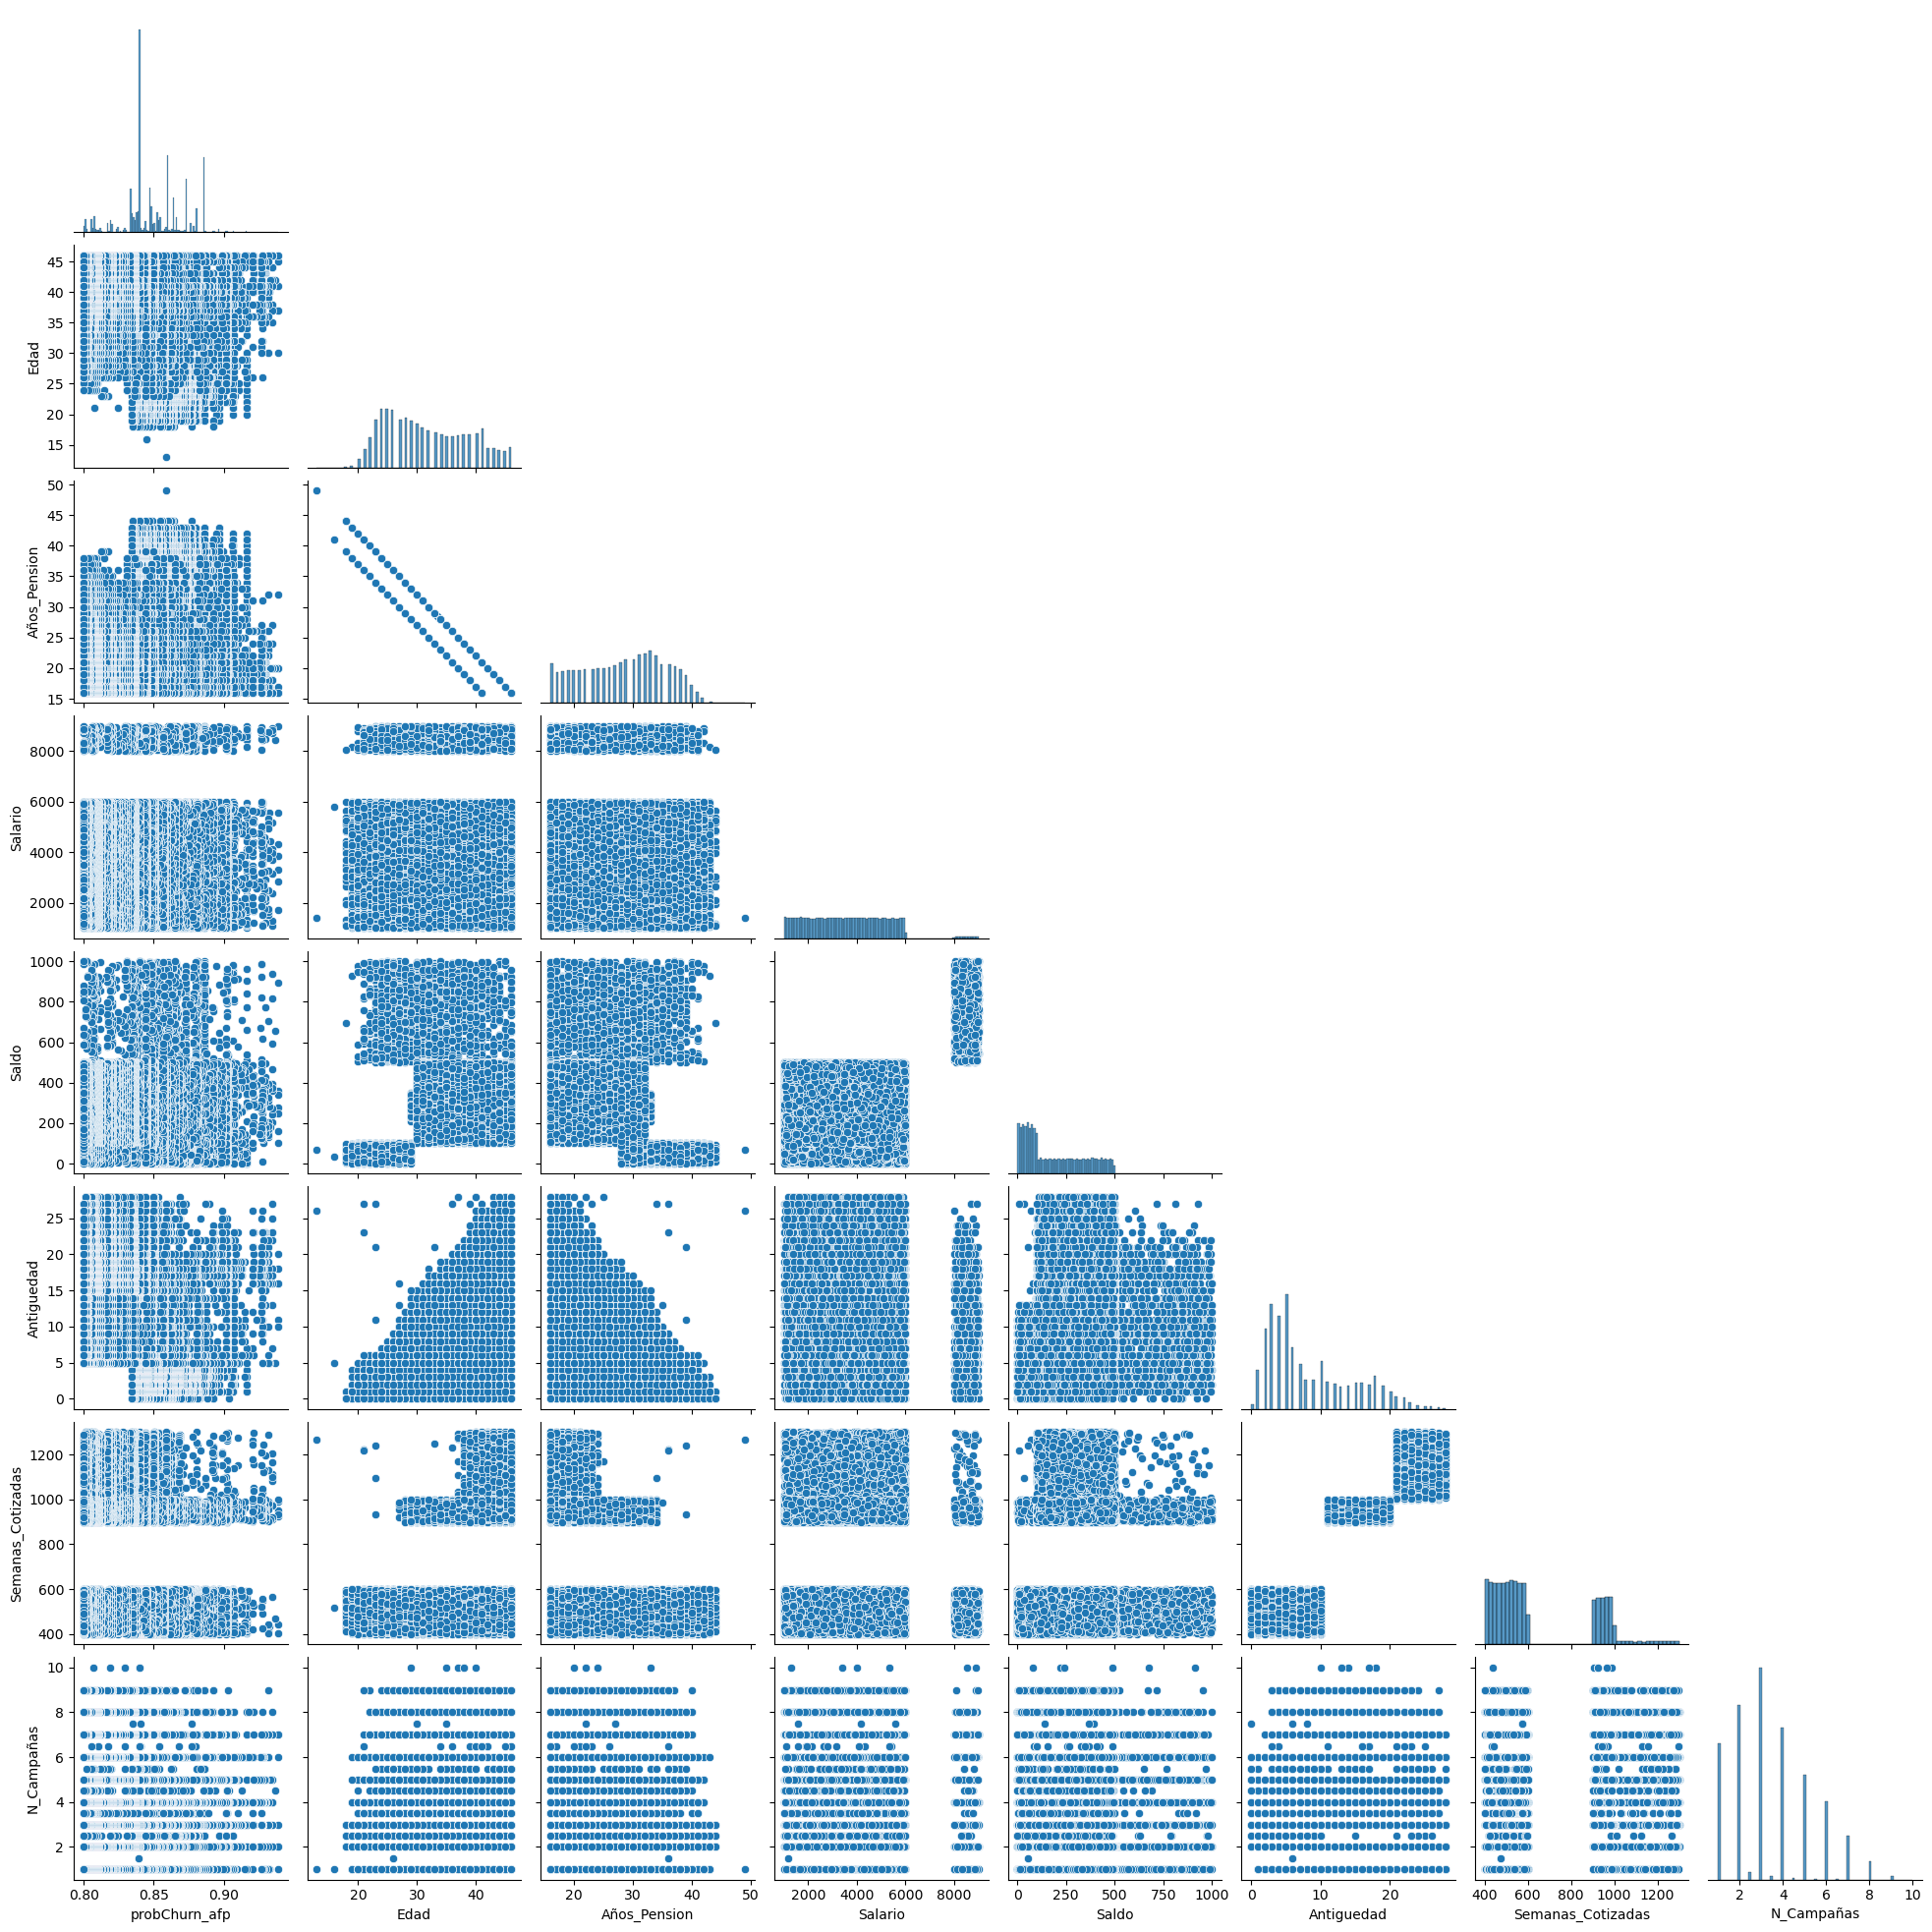

In [14]:
sns.pairplot(data=df_v2, corner=True)
plt.show()

### Matriz de correlación

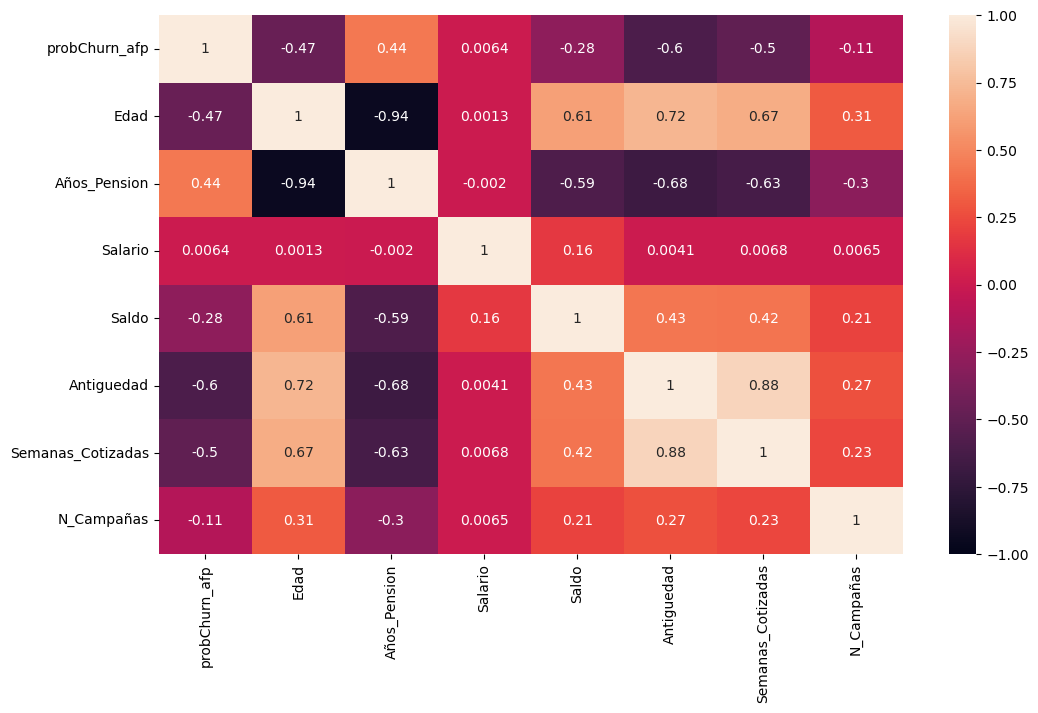

In [15]:
plt.figure(figsize=(12, 7))
df_v3 = df_v2
sns.heatmap(
    df_v3.select_dtypes(include='number').corr(),
    annot=True,
    vmin=-1,
    vmax=1
)
plt.show()

### Analisis de matriz de correlación

De acuerdo a lo que vemos en la gráfica de correlación se puede concluir lo siguiente:
* Hay una correlación positiva bastante significativa entre semanas cotizadas y  la antiguedad lo cual es algo esperado.
* Hay una correlación negativa bastante significativa entre edad y años pensión lo que significa que a mayor edad el valor de años de pensión debe ser menor.
* 2 variables adicionales que poseen tambien correlaciones negativas destacables con años de pension son las variables antiguedad y semanas cotizadas.
* 3 variables que mantienen correlacion positiva con edad son saldo, antiguedad y semanas cotizadas.

### Prueba de multicolinealidad

In [16]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

In [17]:
df_numeric = df_v3.select_dtypes(include='number')
df_numeric = df_numeric.drop(['probChurn_afp'],axis=1)
df_numeric = df_numeric.replace([np.inf, -np.inf], np.nan)
df_numeric = df_numeric.dropna()

In [18]:
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor
X = add_constant(df_numeric)
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                   for i in range(X.shape[1])]
print(vif_data)

             feature         VIF
0              const  628.681279
1               Edad    9.967377
2       Años_Pension    8.350502
3            Salario    1.045146
4              Saldo    1.683120
5         Antiguedad    5.181897
6  Semanas_Cotizadas    4.491027
7         N_Campañas    1.115357


Se observa una fuerte multicolinealidad entre edad, Años_Pension y antiguedad por lo que dado que edad es necesario para el tema de calculo de retencion y la antiguedad puede darno un indicativo de posible permanenecia se eliminara unicamente la variable años_pension para determinar cuanta multicolinealidad aún hay

In [19]:
(df_v3.isnull().sum()/(len(df_v3)))*100

Fondo_Destino        0.000000
Tipo_Id              0.000000
Traslado             0.000000
probChurn_afp        0.000000
Cla_Value_Cliente    0.000000
Productos            0.000983
Ruta_Porvenir        0.000000
Segmento             0.000000
Genero               0.000000
Edad                 0.000000
Años_Pension         0.000000
Salario              0.000000
Saldo                0.000983
Ciudad               0.001966
Departamento         0.001966
Antiguedad           0.000000
Semanas_Cotizadas    0.000000
Cla_Densidad_Cot     0.000000
Tipo_Cotizante_PO    0.000000
Estado               0.000000
SubEstado            0.000000
Tipo_Afiliado        0.000000
Observaciones        0.000983
Grupo                0.000000
N_Campañas           0.069796
dtype: float64

Dado que a pesar de los ajustes implementados en algunas de las variables aún quedan algunas variables con missing values pero son un porcentaje infimo (menos del 1%) se decide por eliminar los datos con missing values, dado que su impacto será ínfimo en los modelos.

In [20]:
df_v3 = df_v3.dropna()

In [21]:
df_v4 = df_v3.drop(['Años_Pension'],axis=1)
df_numeric = df_v4.select_dtypes(include='number')
df_numeric = df_numeric.drop(['probChurn_afp'],axis=1)
df_numeric = df_numeric.replace([np.inf, -np.inf], np.nan)
df_numeric = df_numeric.dropna()

In [22]:
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor
X = add_constant(df_numeric)
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                   for i in range(X.shape[1])]
print(vif_data)

             feature        VIF
0              const  51.670027
1               Edad   2.847341
2            Salario   1.045091
3              Saldo   1.679761
4         Antiguedad   5.181681
5  Semanas_Cotizadas   4.490592
6         N_Campañas   1.114069


Tras la eliminacion de la variable causal de la multicolinealidad ya tenemos un VIF adecuado para la construccion del modelo estadístico.

## Construccion modelos

Para la construcción de los modelos se decidio tomar como variable respuesta la variable *probChurn_afp* ya que es la que parece que es la esperada a modelar en esta prueba y usare un modelo de regresión basica y uno de clasificación paradeterminar cual podría ser la mejor opción

In [23]:
df_v4.head(2)

,Fondo_Destino,Tipo_Id,Traslado,probChurn_afp,Cla_Value_Cliente,Productos,Ruta_Porvenir,Segmento,Genero,Edad,...,Antiguedad,Semanas_Cotizadas,Cla_Densidad_Cot,Tipo_Cotizante_PO,Estado,SubEstado,Tipo_Afiliado,Observaciones,Grupo,N_Campañas
0,2-AFP,CC,NO,0.9167,Entre 5MM y <10MM,PO,CONSTRUYENDO,PLATINO,M,46.0,...,5.0,529,Mayor o igual 75%,Activo,VIGENTE,TRASLADO_ENTRADA,DEPENDIENTE,Correo_Celular,Mayor_Valor,7.0
1,2-AFP,CC,NO,0.9167,Entre 5MM y <10MM,PO,CONSTRUYENDO,DORADO,M,39.0,...,2.0,568,Mayor o igual 75%,Activo,VIGENTE,TRASLADO_ENTRADA,INDEPENDIENTE_VOLUNTARIO,Celular,Mayor_Valor,3.0


In [24]:
X = pd.get_dummies(df_v4.drop(columns=['probChurn_afp']), drop_first=True)
X = X.fillna(X.median())
y = df_v4['probChurn_afp']

In [25]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Modelo de regresion lineal

In [27]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])
pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)
print("Regresión Lineal")
print("RMSE:", rmse_lr)
print("MAE:", mae_lr)
print("R2:", r2_lr)

Regresión Lineal
RMSE: 0.01645055673179433
MAE: 0.01263243300382316
R2: 0.42193787928801174


### Modelo random forrest

In [28]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
print("\nRandom Forest")
print("RMSE:", rmse_rf)
print("MAE:", mae_rf)
print("R2:", r2_rf)


Random Forest
RMSE: 0.014772658928060173
MAE: 0.010182795622233547
R2: 0.5338446711728713


### Comparaciones

In [29]:
results = pd.DataFrame({
    "Modelo": ["Regresión Lineal", "Random Forest"],
    "RMSE": [rmse_lr, rmse_rf],
    "MAE": [mae_lr, mae_rf],
    "R2": [r2_lr, r2_rf]
})
print(results)

             Modelo      RMSE       MAE        R2
0  Regresión Lineal  0.016451  0.012632  0.421938
1     Random Forest  0.014773  0.010183  0.533845


Los resultados muestran mejor resultado en un modelo de random forrest comparado con el modelo de regresión lineal esto sugiere la presencia de relaciones no lineales entre las variables explicativas y probChurn_afp, por lo que se proseguirá con este modelo, y para obtener un mejor resultado se aplicará un cross validation en 5 folds para evitar sobreajuste

In [31]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_validate
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
scoring = {
    'rmse': 'neg_root_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'r2': 'r2'
}

cv_results = cross_validate(
    rf,
    X_train,
    y_train,
    cv=5,
    scoring=scoring,
    return_train_score=False
)

print("Cross Validation Results (5 folds)")
print("RMSE:", -cv_results['test_rmse'].mean())
print("MAE:", -cv_results['test_mae'].mean())
print("R2:", cv_results['test_r2'].mean())

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("\nRandom Forest Test Results")
print("RMSE:", rmse_rf)
print("MAE:", mae_rf)
print("R2:", r2_rf)

Cross Validation Results (5 folds)
RMSE: 0.01484119068417781
MAE: 0.010255864086326021
R2: 0.5385889715041277

Random Forest Test Results
RMSE: 0.014772658928060173
MAE: 0.010182795622233547
R2: 0.5338446711728713


* El modelo Random Forest muestra un rendimiento estable entre validación cruzada y conjunto de prueba.
* El RMSE promedio obtenido en cross-validation fue 0.0148, igual que en el conjunto de test, indicando buena capacidad de generalización.
* El modelo explica aproximadamente el 54% de la variabilidad del target (R² = 0.5338), lo que sugiere que captura una parte significativa de las relaciones en los datos aunque aún existe un margen de mejora considerable para el modelo.

Dado que los resultados no son lo suficientemente buenos en R² se procede a ensayar con lightgbm para ver posibles margenes de mejoría y comparar hasta decidir cual puede ser mejor el modelo sin tener que buscar como complementar la base de datos.

Para ello se evalúa primero que variables siguen siendo relevantes

In [30]:
feat_importances = pd.Series(rf.feature_importances_, index=X_train.columns)
feat_importances.sort_values(ascending=False).head(10)

Antiguedad                       0.398740
Fondo_Destino_2-AFP              0.104802
Salario                          0.071506
Saldo                            0.065078
Semanas_Cotizadas                0.063829
Cla_Value_Cliente_Menor a 2MM    0.049414
Edad                             0.036962
N_Campañas                       0.026509
Genero_M                         0.007571
Observaciones_Correo_Celular     0.006135
dtype: float64

Se construye el modelo de lightgbm y su posterior comparación con el modelo de RF

In [32]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [33]:
#xgb = XGBRegressor(
#    n_estimators=300,
#    learning_rate=0.05,
#    max_depth=6,
#    subsample=0.8,
#    colsample_bytree=0.8,
#    random_state=42
#)

lgbm = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    random_state=42
)

In [38]:
models = {
    "Random Forest": rf,
    #"XGBoost": xgb,
    "LightGBM": lgbm
}

In [39]:
scoring = {
    'rmse': 'neg_root_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'r2': 'r2'
}

In [40]:
results = []

for name, model in models.items():

    # Cross Validation
    cv = cross_validate(
        model,
        X_train,
        y_train,
        cv=5,
        scoring=scoring
    )

    cv_rmse = -cv['test_rmse'].mean()
    cv_mae = -cv['test_mae'].mean()
    cv_r2 = cv['test_r2'].mean()

    # Train final model
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    test_mae = mean_absolute_error(y_test, y_pred)
    test_r2 = r2_score(y_test, y_pred)

    results.append([
        name,
        cv_rmse,
        cv_mae,
        cv_r2,
        test_rmse,
        test_mae,
        test_r2
    ])

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003251 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1351
[LightGBM] [Info] Number of data points in the train set: 65056, number of used features: 261
[LightGBM] [Info] Start training from score 0.849251
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002702 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1344
[LightGBM] [Info] Number of data points in the train set: 65056, number of used features: 258
[LightGBM] [Info] Start training from score 0.849226
[LightGBM] [Warning] Found

In [41]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "CV RMSE",
        "CV MAE",
        "CV R2",
        "Test RMSE",
        "Test MAE",
        "Test R2"
    ]
)

print(results_df.sort_values("Test RMSE"))

           Model   CV RMSE    CV MAE     CV R2  Test RMSE  Test MAE   Test R2
1       LightGBM  0.014518  0.010171  0.558445   0.014397  0.010077  0.557269
0  Random Forest  0.014841  0.010256  0.538589   0.014773  0.010183  0.533845


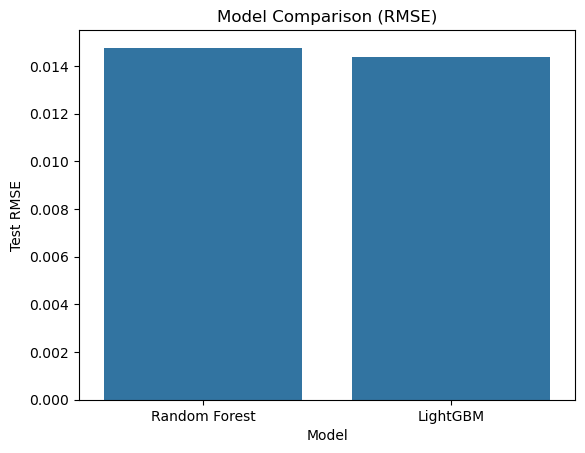

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=results_df, x="Model", y="Test RMSE")
plt.title("Model Comparison (RMSE)")
plt.show()

### Conclusiones finales

* El modelo Random Forest presenta mejor desempeño de generalización aunque la diferencia no es muy considerable que digamos, sin embargo LightGBM muestra un mejor desempeño de modelo, lo que indica que si quisieramos explicar un poco mejor el que tanto la variables que poseemos afectan a la variable prob_churn sería a traves del uso del modelo LightGBM.
* Las variables mas relevantes para mejorar el modelo así como para empezar a definir mejor como empezar a fidelizar clientes sería con variables como **antiguedad**, si el **Fondo_Destino** es AFP privada, **saldo**, **semanas_cotizadas**, **edad**, **Salario**, **estado** y **subestado**.
* Aunque el modelo es moderadamente bueno, posee un gran margen de mejora a través de una aumento históricode la información o con la incorporacion de nuevas variables a traves del cruce con la información de una database de la cual se tenga poseción.